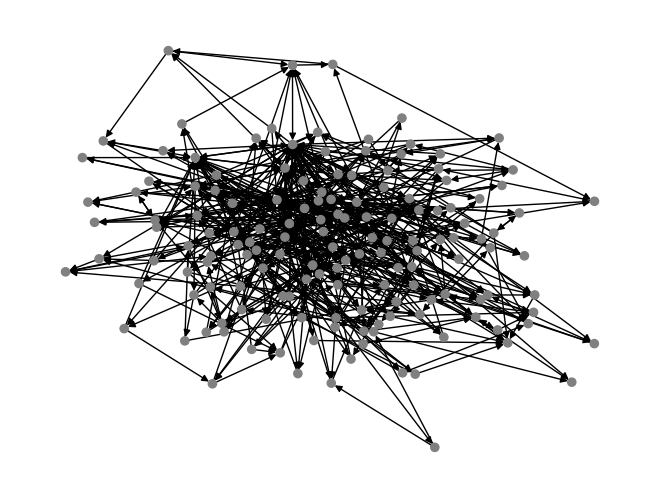

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random

class SocialNetowrk():
    def __init__(self, n=100, k=1):
        self.n=n
        self.k=k
        self.pops = [0]*4
        Insample = nx.barabasi_albert_graph(n, k)        
        InAmatrix = self.weight_Amatrix_Poisson(np.triu(nx.to_numpy_array(Insample)))
        
        Outsample = nx.barabasi_albert_graph(n, k)        
        OutAmatrix = self.weight_Amatrix_Poisson(np.tril(nx.to_numpy_array(Outsample)))

        SampleAmatrix = InAmatrix + OutAmatrix
        
        self.G = nx.from_numpy_array(SampleAmatrix,create_using=nx.DiGraph)
        for id in self.G.nodes:
            self.G.nodes[id]["state"] = 0
            self.G.nodes[id]["immunity"] = 0
            self.G.nodes[id]["i2z"] = 0
            
    def weight_Amatrix_Poisson(self,Amatrix):
            for i,node in enumerate(Amatrix):

                neighbors = np.where(node == 1)[0]
                weights = np.zeros(self.n)

                poisson_vals = np.random.poisson(self.k, len(neighbors))
                weights[neighbors] = poisson_vals

                if weights.sum() == 0:
                    continue

                Amatrix[i] = weights / weights.sum()
            return Amatrix
    
    def show(self, ax=None):
        layout = nx.spring_layout(self.G,seed=10)

        state_to_color = {
            0: "gray",
            1: "orange",
            2: "green",
            3: "brown",
        }

        colors = [state_to_color[self.G.nodes[i]["state"]] for i in self.G.nodes]

        nx.draw(self.G, pos=layout,
                node_size=35,
                node_color=colors)

        # Legend
        legend_items = [
            mpatches.Patch(color="gray", label="Healthy (0)"),
            mpatches.Patch(color="orange", label="Infected (1)"),
            mpatches.Patch(color="green", label="Zombie (2)"),
            mpatches.Patch(color="brown", label="Dead (3)")

        ]
        #axs[0].legend(handles=legend_items)
        degree_dist = nx.degree_histogram(self.G)
        plt.savefig("emptynetwork.jpg")
    def show_degree_centrality(self):
        centrality = nx.degree_centrality(self.G)
        plt.grid(True)
        plt.title("degree centrality")
        plt.xlabel("node")
        plt.ylabel("centrality")
        plt.plot(centrality.keys(),centrality.values())
        plt.show()

network = SocialNetowrk(n=150,k=2)
network.show()